###### 129_7_defect_ppm_qcut_graph_practice.ipynb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["font.family"] = "Meiryo"

In [3]:
df = pd.DataFrame(
    {
         "site": [
            "SUS",
            "SUS",
            "WSE",
            "WSE",
            "GSE",
            "GSE",
            "MELMB",
            "MELMB",
            "ISE",
            "ISE",
            "SUS",
            "GSE",
        ],
             "model": [
            "J69P",
            "J69P",
            "310D",
            "310D",
            "KLZB",
            "KLZB",
            "J69P",
            "310D",
            "KLZB",
            "J69P",
            "310D",
            "KLZB",
        ],
        "defect_category": [
            "コイル",
            "Buck-IC",
            "コイル",
            "NTF",
            "MCU",
            "コイル",
            "Buck-IC",
            "NTF",
            "MCU",
            "コイル",
            "コイル",
            "Buck-IC",
        ],
        "inspection_qty": [
            12000,
            18000,
            15000,
            22000,
            16000,
            25000,
            30000,
            28000,
            21000,
            19000,
            26000,
            32000,
        ],
        "defect_qty": [
            2,
            5,
            3,
            1,
            4,
            8,
            6,
            2,
            7,
            3,
            10,
            12,
        ],
    }
)

In [4]:
df_work = df.copy()
df_work

,site,model,defect_category,inspection_qty,defect_qty
0,SUS,J69P,コイル,12000,2
1,SUS,J69P,Buck-IC,18000,5
2,WSE,310D,コイル,15000,3
3,WSE,310D,NTF,22000,1
4,GSE,KLZB,MCU,16000,4
5,GSE,KLZB,コイル,25000,8
6,MELMB,J69P,Buck-IC,30000,6
7,MELMB,310D,NTF,28000,2
8,ISE,KLZB,MCU,21000,7
9,ISE,J69P,コイル,19000,3


In [5]:
df_work["defect_rate"] = (
    df_work["defect_qty"]
    / df_work["inspection_qty"]
)
df_work

,site,model,defect_category,inspection_qty,defect_qty,defect_rate
0,SUS,J69P,コイル,12000,2,0.000167
1,SUS,J69P,Buck-IC,18000,5,0.000278
2,WSE,310D,コイル,15000,3,0.000200
3,WSE,310D,NTF,22000,1,0.000045
4,GSE,KLZB,MCU,16000,4,0.000250
5,GSE,KLZB,コイル,25000,8,0.000320
6,MELMB,J69P,Buck-IC,30000,6,0.000200
7,MELMB,310D,NTF,28000,2,0.000071
8,ISE,KLZB,MCU,21000,7,0.000333
9,ISE,J69P,コイル,19000,3,0.000158


In [6]:
df_work["defect_ppm"] = (
    df_work["defect_rate"] * 1000000
)
df_work

,site,model,defect_category,inspection_qty,defect_qty,defect_rate,defect_ppm
0,SUS,J69P,コイル,12000,2,0.000167,166.666667
1,SUS,J69P,Buck-IC,18000,5,0.000278,277.777778
2,WSE,310D,コイル,15000,3,0.000200,200.000000
3,WSE,310D,NTF,22000,1,0.000045,45.454545
4,GSE,KLZB,MCU,16000,4,0.000250,250.000000
5,GSE,KLZB,コイル,25000,8,0.000320,320.000000
6,MELMB,J69P,Buck-IC,30000,6,0.000200,200.000000
7,MELMB,310D,NTF,28000,2,0.000071,71.428571
8,ISE,KLZB,MCU,21000,7,0.000333,333.333333
9,ISE,J69P,コイル,19000,3,0.000158,157.894737


In [7]:
labels = [
    "低い",
    "やや低い",
    "やや高い",
    "高い",
]

In [8]:
#cell8
df_work["ppm_quartile_category"] = pd.qcut(
    df_work["defect_ppm"],
    4,
    labels=labels,
)
df_work

,site,model,defect_category,inspection_qty,defect_qty,defect_rate,defect_ppm,ppm_quartile_category
0,SUS,J69P,コイル,12000,2,0.000167,166.666667,やや低い
1,SUS,J69P,Buck-IC,18000,5,0.000278,277.777778,やや高い
2,WSE,310D,コイル,15000,3,0.000200,200.000000,やや低い
3,WSE,310D,NTF,22000,1,0.000045,45.454545,低い
4,GSE,KLZB,MCU,16000,4,0.000250,250.000000,やや高い
5,GSE,KLZB,コイル,25000,8,0.000320,320.000000,やや高い
6,MELMB,J69P,Buck-IC,30000,6,0.000200,200.000000,やや低い
7,MELMB,310D,NTF,28000,2,0.000071,71.428571,低い
8,ISE,KLZB,MCU,21000,7,0.000333,333.333333,高い
9,ISE,J69P,コイル,19000,3,0.000158,157.894737,低い


In [11]:
#cell9
df_quartile_count = df_work["ppm_quartile_category"].value_counts(
    sort=False
).reset_index()
df_quartile_count

df_quartile_count.columns = [
    "ppm_quartile_category",
    "count",
]

df_quartile_count

,ppm_quartile_category,count
0,低い,3
1,やや低い,3
2,やや高い,3
3,高い,3


In [12]:
df_high_ppm = df_work[
    df_work["ppm_quartile_category"] == "高い"
].copy()
df_high_ppm

,site,model,defect_category,inspection_qty,defect_qty,defect_rate,defect_ppm,ppm_quartile_category
8,ISE,KLZB,MCU,21000,7,0.000333,333.333333,高い
10,SUS,310D,コイル,26000,10,0.000385,384.615385,高い
11,GSE,KLZB,Buck-IC,32000,12,0.000375,375.000000,高い


In [13]:
q1 = df_work["defect_ppm"].quantile(0.25)
q2 = df_work["defect_ppm"].quantile(0.50)
q3 = df_work["defect_ppm"].quantile(0.75)

q1, q2, 13

(np.float64(164.4736842105263), np.float64(225.0), 13)

In [14]:
plt.figure(
    figsize=(
        10,
        5
    )
)

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

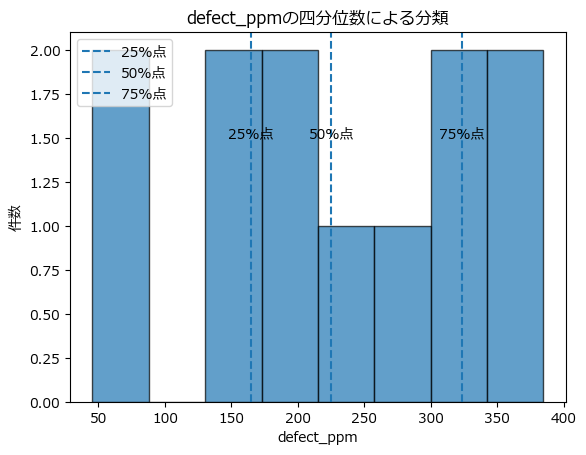

In [30]:
#cell13

plt.hist(
    df_work["defect_ppm"],
    bins=8,
    alpha=0.7,
    edgecolor="black",
)
#cell14
plt.axvline(
    q1,
    linestyle="--",
    label="25%点",
)

plt.axvline(
    q2,
    linestyle="--",
    label="50%点",
)

plt.axvline(
    q3,
    linestyle="--",
    label="75%点",
)

#cell 15
plt.text(
    q1,
    1.5,
    "25%点",
    ha="center",
)

plt.text(
    q2,
    1.5,
    "50%点",
    ha="center",
)
plt.text(
    q3,
    1.5,
    "75%点",
    ha="center"
)

plt.title("defect_ppmの四分位数による分類")
plt.xlabel("defect_ppm")
plt.ylabel("件数")
plt.legend()
plt.show()